<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Project4/blob/main/Project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Unsupervised Image Clustering and Visualization

In [2]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from collections import Counter

In [3]:
# 2. Load Dataset
digits = load_digits()

# 3. Features and Labels
X = digits.data
y = digits.target

In [5]:
# 4. Print Dataset Shape

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

Dataset Shape: (1797, 64)
Target Shape: (1797,)


In [6]:
# 5. Normalize Images
X = X / 16.0

# 6. Check Pixel Range
print(X.min())
print(X.max())

0.0
1.0


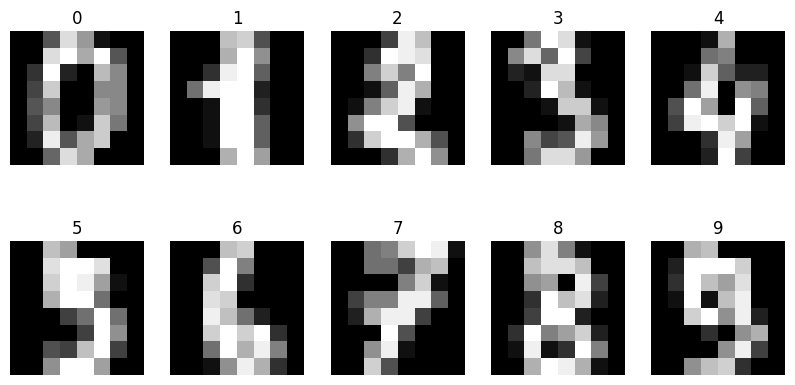

In [7]:
# 7. Exploratory Data Analysis (EDA)
pd.Series(y).value_counts()

# 8. Display Sample Images

fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(y[i])
    ax.axis('off')

plt.show()


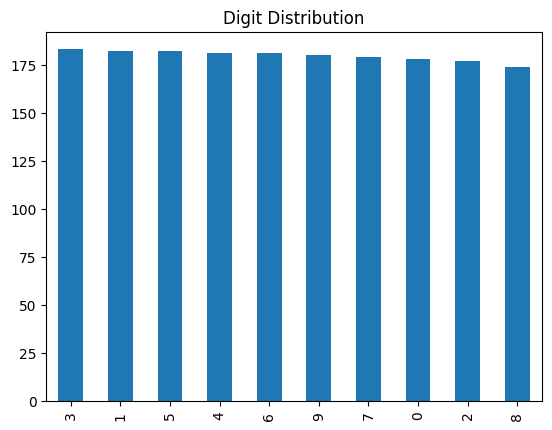

In [8]:
# 9. Bar Chart of Class Distribution

pd.Series(y).value_counts().plot(kind='bar')
plt.title("Digit Distribution")
plt.show()


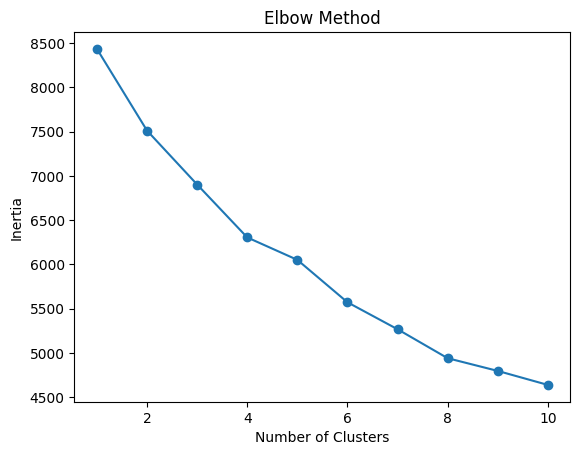

In [9]:
# 10. Elbow Method

inertia = []

K = range(1, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [10]:
# 11. Train Final K-Means Model

kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

kmeans.fit(X)


KMeans(n_clusters=10, random_state=42)

In [11]:
# 12. Cluster Labels

cluster_labels = kmeans.labels_
print(cluster_labels)

# 13. Count Cluster Size

cluster_counts = Counter(cluster_labels)
print(cluster_counts)


[5 7 7 ... 8 9 8]
Counter({np.int32(9): 248, np.int32(0): 193, np.int32(2): 181, np.int32(5): 178, np.int32(6): 173, np.int32(3): 173, np.int32(8): 172, np.int32(7): 167, np.int32(4): 166, np.int32(1): 146})


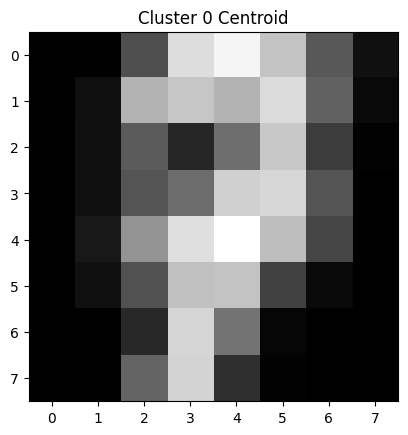

In [12]:
# 14. Cluster Centroids

centers = kmeans.cluster_centers_

plt.imshow(
    centers[0].reshape(8,8),
    cmap='gray'
)

plt.title("Cluster 0 Centroid")
plt.show()


In [13]:
# 15. Predict New Images

new_images = X[:10]

predictions = kmeans.predict(new_images)

print(predictions)


[5 7 7 6 4 9 2 0 8 9]


In [14]:
# 16. Confusion Matrix

cm = confusion_matrix(
    y,
    cluster_labels
)

print(cm)


[[  0   0   0   0   2 176   0   0   0   0]
 [  0   1   2  23   0   0   1 130   3  22]
 [  2   0   0 146   0   1  12   6   9   1]
 [  7   2   0   1   0   0 159   0   6   8]
 [  5   0   0   0 159   0   0  13   4   0]
 [  0 137   2   0   2   0   0   0   0  41]
 [  0   0 176   0   0   1   0   3   1   0]
 [169   0   0   0   0   0   0   0  10   0]
 [  2   2   1   3   0   0   0  14 136  16]
 [  8   4   0   0   3   0   1   1   3 160]]


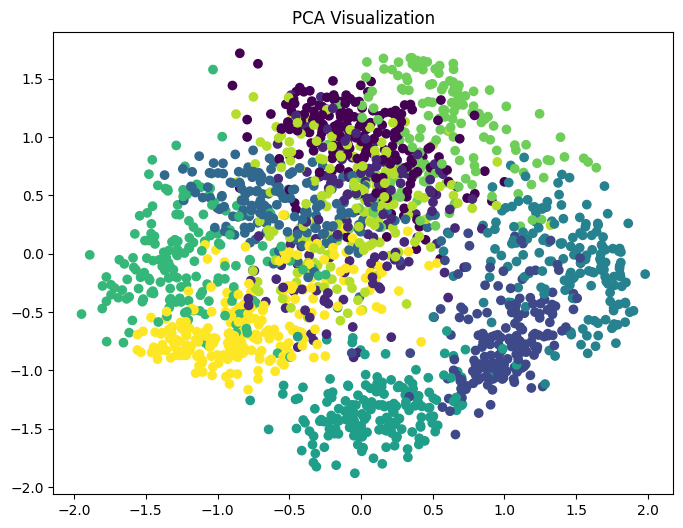

In [15]:
# 17. PCA (Dimensionality Reduction)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# PCA Visualization

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels
)

plt.title("PCA Visualization")
plt.show()


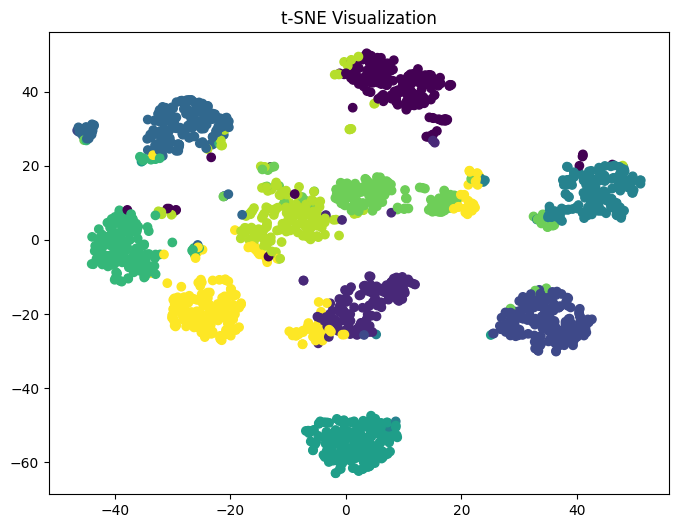

In [16]:
# 18. t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

# t-SNE Visualization

plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=cluster_labels
)

plt.title("t-SNE Visualization")
plt.show()



In [17]:
# 19. Cluster Composition

cluster = 3
indices = np.where(
    cluster_labels == cluster
)[0]
labels = y[indices]

print(pd.Series(labels).value_counts())


2    146
1     23
8      3
3      1
Name: count, dtype: int64
